# 13 — Ablation: Augmentation without AKIEC

**Goal:** test whether the -10 percentage-point AKIEC regression in the original Phase 10 augmented run was caused by poor-quality synthetic AKIEC samples or by something else.

**Background.** In Phase 10, augmentation lifted overall macro-F1 from 0.550 to 0.603 and helped five of the seven classes — but AKIEC recall *dropped* from 0.551 to 0.449 despite receiving 1,542 synthetic samples (more than any class except DF). The most likely explanation is that the CVAE-generated AKIEC images are visually closer to BCC or BKL than to real AKIEC, so they teach the model the wrong decision boundary for that class.

**What this notebook does.** Run the exact same training recipe as Phase 10 (`09_train_augmented.ipynb`) with one change: remove AKIEC (`class_idx = 3`) from `SOURCES_PER_CLASS`. The baseline run does not change — we reuse the Phase 5 baseline numbers for the comparison.

**Two possible outcomes, both interesting for the report:**

1. **Overall macro-F1 goes up and AKIEC recall recovers** → the synthetic AKIEC samples were actively harmful. Conclusion: generative augmentation works, but quality of generated samples per class matters more than quantity.
2. **Overall macro-F1 stays flat or drops and AKIEC recall stays similar** → the synthetic AKIEC samples weren't great but they were doing some real work. Conclusion: even noisy synthetic data can carry useful class signal.

Either way the project has a sharper, more honest story than "augmentation helped on average."

**Reference:** mirrors `09_train_augmented.ipynb` (Phase 10) exactly except for the `SOURCES_PER_CLASS` change.

## 1. Imports, paths, seed

In [1]:
import sys
from pathlib import Path
import csv
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, recall_score,
)

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import ISICDataset, CLASS_NAMES, get_class_weights        # noqa: E402
from src.dataset_augmented import AugmentedISICDataset                      # noqa: E402
from src.models.classifier import build_resnet50_classifier                 # noqa: E402

SPLITS_CSV = PROJECT_ROOT / 'data' / 'processed' / 'splits.csv'
IMAGES_DIR = PROJECT_ROOT / 'data' / 'raw' / 'ISIC2018_Task3_Training_Input'
MANIFEST   = PROJECT_ROOT / 'data' / 'synthetic' / 'synthetic_manifest.csv'

RESULTS    = PROJECT_ROOT / 'results'
CKPT_DIR   = RESULTS / 'checkpoints'
LOGS_DIR   = RESULTS / 'logs'
PLOTS_DIR  = RESULTS / 'plots'
for d in (CKPT_DIR, LOGS_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert SPLITS_CSV.exists(), f'splits.csv not found at {SPLITS_CSV}'
assert MANIFEST.exists(),   f'synthetic_manifest.csv not found at {MANIFEST}'

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f'Seed fixed to {SEED}')

Seed fixed to 42


## 2. Device check

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU detected. Single epoch on CPU will take hours.')

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
CUDA memory: 85.1 GB


## 3. Hyperparameters

**Identical to Phase 10** — frozen backbone, head-only training, same LR, same patience, same batch size. The ONLY change is `SOURCES_PER_CLASS`: AKIEC (`class_idx = 3`) is removed.

In [3]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 40
LR            = 1e-3
PATIENCE      = 7
NUM_WORKERS   = 2
N_CLASSES     = len(CLASS_NAMES)

# Phase 10 used:    {2: 'cvae', 3: 'cvae', 5: 'cvae', 6: 'cvae'}
# Notebook 13 uses (AKIEC removed):
SOURCES_PER_CLASS = {
    2: 'cvae',    # BCC
    5: 'cvae',    # DF
    6: 'cvae',    # VASC
}

print(f'image size      : {IMG_SIZE}')
print(f'batch size      : {BATCH_SIZE}')
print(f'epochs          : {EPOCHS}')
print(f'lr              : {LR}')
print(f'patience        : {PATIENCE}')
print(f'sources per cls : {SOURCES_PER_CLASS}')
print(f'AKIEC removed   : yes (was 1542 CVAE samples in Phase 10)')

image size      : 224
batch size      : 32
epochs          : 40
lr              : 0.001
patience        : 7
sources per cls : {2: 'cvae', 5: 'cvae', 6: 'cvae'}
AKIEC removed   : yes (was 1542 CVAE samples in Phase 10)


## 4. Transforms

Identical to Phase 10.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## 5. Datasets and loaders

Three things to load: the augmented training set (real + CVAE for BCC/DF/VASC only), the real val set, the real test set.

In [5]:
train_ds = AugmentedISICDataset(
    splits_csv=SPLITS_CSV, images_dir=IMAGES_DIR,
    synth_manifest_csv=MANIFEST, project_root=PROJECT_ROOT,
    split='train', transform=train_tf,
    sources_per_class=SOURCES_PER_CLASS,
)
val_ds  = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='val',  transform=eval_tf)
test_ds = ISICDataset(SPLITS_CSV, IMAGES_DIR, split='test', transform=eval_tf)

print(f'train  : {len(train_ds):>6,}  (real + synthetic for BCC/DF/VASC)')
print(f'val    : {len(val_ds):>6,}')
print(f'test   : {len(test_ds):>6,}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

train  : 11,916  (real + synthetic for BCC/DF/VASC)
val    :  1,503
test   :  1,503


## 6. Class weights

Same as Phase 5 / Phase 10 — computed from REAL train counts only. This keeps the loss landscape comparable across runs.

In [6]:
class_weights = get_class_weights(SPLITS_CSV, split='train').to(DEVICE)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:<6} idx={i}  weight={class_weights[i].item():.4f}')

  MEL    idx=0  weight=1.2853
  NV     idx=1  weight=0.2134
  BCC    idx=2  weight=2.7813
  AKIEC  idx=3  weight=4.3724
  BKL    idx=4  weight=1.3021
  DF     idx=5  weight=12.5161
  VASC   idx=6  weight=10.1140


## 7. EarlyStopping

In [7]:
class EarlyStopping:
    # Stops training when validation loss stops improving for `patience` epochs.

    def __init__(self, patience: int = 5, delta: float = 0.0):
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False

    def check_early_stop(self, val_loss: float):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True

## 8. Train / evaluate helpers

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0; correct = 0; total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0; correct = 0; total = 0
    all_preds = []; all_labels = []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(y.cpu().tolist())
    return (total_loss / total, correct / total,
            f1_score(all_labels, all_preds, average='macro', zero_division=0),
            balanced_accuracy_score(all_labels, all_preds),
            all_preds, all_labels)

## 9. Model, optimiser, loss

Frozen backbone, head-only training — exactly the same recipe as Phase 5 and Phase 10.

In [9]:
model = build_resnet50_classifier(num_classes=N_CLASSES, freeze_backbone=True).to(DEVICE)
trainable = [p for p in model.parameters() if p.requires_grad]
print(f'trainable params: {sum(p.numel() for p in trainable):,}')

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(trainable, lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3,
)

trainable params: 14,343


## 10. Training loop

Identical structure to Phase 10. Logs to CSV, saves best checkpoint by val macro-F1, early-stops on val loss.

In [10]:
EXPERIMENT_NAME = 'augmented_no_akiec'
log_path  = LOGS_DIR / f'{EXPERIMENT_NAME}_log.csv'
ckpt_path = CKPT_DIR / f'{EXPERIMENT_NAME}_best.pt'

with open(log_path, 'w', newline='') as f:
    csv.writer(f).writerow(
        ['epoch', 'train_loss', 'train_acc', 'val_loss',
         'val_acc', 'val_macro_f1', 'val_balanced_acc']
    )

history = {k: [] for k in ['epoch', 'train_loss', 'train_acc',
                            'val_loss', 'val_acc', 'val_macro_f1', 'val_balanced_acc']}
best_val_f1 = -1.0
early_stopper = EarlyStopping(patience=PATIENCE)
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_start = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc, val_f1, val_bal, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['epoch'].append(epoch)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_macro_f1'].append(val_f1)
    history['val_balanced_acc'].append(val_bal)

    with open(log_path, 'a', newline='') as f:
        csv.writer(f).writerow(
            [epoch, tr_loss, tr_acc, val_loss, val_acc, val_f1, val_bal]
        )

    marker = ''
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_macro_f1': val_f1}, ckpt_path)
        marker = '  <-- new best, saved'

    dt = time.time() - ep_start
    print(f'epoch {epoch:>2}/{EPOCHS}  '
          f'train_loss={tr_loss:.4f} acc={tr_acc:.4f}  '
          f'val_loss={val_loss:.4f} acc={val_acc:.4f} f1={val_f1:.4f}  '
          f'({dt:.1f}s){marker}')

    early_stopper.check_early_stop(val_loss)
    if early_stopper.stop_training:
        print(f'early stopping at epoch {epoch}')
        break

print(f'\\ntraining done in {(time.time()-t0)/60:.1f} min, best val_macro_f1={best_val_f1:.4f}')

epoch  1/40  train_loss=1.2923 acc=0.4171  val_loss=1.3942 acc=0.6474 f1=0.3975  (53.5s)  <-- new best, saved
epoch  2/40  train_loss=1.1678 acc=0.5175  val_loss=1.2556 acc=0.6307 f1=0.4280  (53.1s)  <-- new best, saved
epoch  3/40  train_loss=1.1364 acc=0.5318  val_loss=1.1918 acc=0.6401 f1=0.4734  (50.3s)  <-- new best, saved
epoch  4/40  train_loss=1.1101 acc=0.5484  val_loss=1.1663 acc=0.5975 f1=0.4158  (49.3s)
epoch  5/40  train_loss=1.0735 acc=0.5601  val_loss=1.1414 acc=0.6248 f1=0.4469  (49.0s)
epoch  6/40  train_loss=1.0703 acc=0.5616  val_loss=1.0731 acc=0.6766 f1=0.4784  (49.5s)  <-- new best, saved
epoch  7/40  train_loss=1.0555 acc=0.5735  val_loss=1.0722 acc=0.6341 f1=0.4612  (49.4s)
epoch  8/40  train_loss=1.0487 acc=0.5773  val_loss=1.0712 acc=0.6613 f1=0.4842  (50.2s)  <-- new best, saved
epoch  9/40  train_loss=1.0364 acc=0.5826  val_loss=1.0473 acc=0.6860 f1=0.4804  (49.6s)
epoch 10/40  train_loss=1.0382 acc=0.5817  val_loss=1.0634 acc=0.6381 f1=0.4577  (49.0s)
epoch

## 11. Training curves

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/no_akiec_curves.png


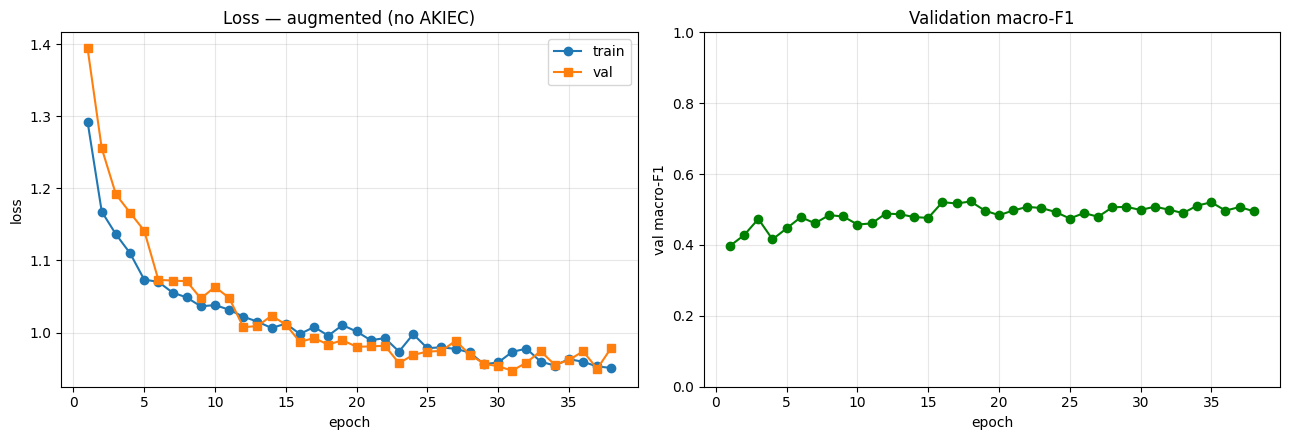

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='train')
axes[0].plot(history['epoch'], history['val_loss'],   marker='s', label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss — augmented (no AKIEC)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['epoch'], history['val_macro_f1'], color='green', marker='o')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('val macro-F1')
axes[1].set_title('Validation macro-F1'); axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
out = PLOTS_DIR / 'no_akiec_curves.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 12. Test-set evaluation

Load the best checkpoint and evaluate on the held-out test set.

In [12]:
ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
ep = ckpt['epoch']
vf = ckpt['val_macro_f1']
print(f'loaded epoch {ep}  (val macro-F1 = {vf:.4f})')

test_loss, test_acc, test_f1, test_bal, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE,
)
print(f'test_loss={test_loss:.4f}  test_acc={test_acc:.4f}  '
      f'test_macro_f1={test_f1:.4f}  test_balanced_acc={test_bal:.4f}')

print('\\nClassification report:')
print(classification_report(test_labels, test_preds,
                            labels=list(range(N_CLASSES)),
                            target_names=CLASS_NAMES,
                            zero_division=0, digits=3))

loaded epoch 18  (val macro-F1 = 0.5227)
test_loss=1.1258  test_acc=0.7126  test_macro_f1=0.4862  test_balanced_acc=0.5726
\nClassification report:
              precision    recall  f1-score   support

         MEL      0.404     0.527     0.457       167
          NV      0.935     0.804     0.865      1006
         BCC      0.557     0.442     0.493        77
       AKIEC      0.281     0.551     0.372        49
         BKL      0.552     0.545     0.549       165
          DF      0.130     0.412     0.197        17
        VASC      0.348     0.727     0.471        22

    accuracy                          0.713      1503
   macro avg      0.458     0.573     0.486      1503
weighted avg      0.776     0.713     0.736      1503



## 13. Three-way comparison — baseline vs augmented (Phase 10) vs augmented-no-AKIEC

The headline table. Read the AKIEC row first.

In [13]:
# Per-class recall from this run
rec_no_akiec = recall_score(test_labels, test_preds,
                            labels=list(range(N_CLASSES)),
                            average=None, zero_division=0)

# Pull Phase 10 results from the existing comparison CSV
phase10_csv = LOGS_DIR / 'comparison_baseline_vs_augmented.csv'
assert phase10_csv.exists(), f'expected Phase 10 comparison at {phase10_csv}'
p10 = pd.read_csv(phase10_csv)

# Build the three-way table
rows = []
for i, name in enumerate(CLASS_NAMES):
    row_p10 = p10[p10['class'] == name].iloc[0]
    rows.append({
        'class': name,
        'baseline_recall':         row_p10['baseline_recall'],
        'augmented_recall':        row_p10['augmented_recall'],
        'no_akiec_recall':         rec_no_akiec[i],
        'delta_vs_baseline':       rec_no_akiec[i] - row_p10['baseline_recall'],
        'delta_vs_augmented':      rec_no_akiec[i] - row_p10['augmented_recall'],
    })

# Overall row (macro-F1)
row_overall = p10[p10['class'] == 'OVERALL'].iloc[0]
rows.append({
    'class': 'OVERALL',
    'baseline_recall':       row_overall['baseline_recall'],
    'augmented_recall':      row_overall['augmented_recall'],
    'no_akiec_recall':       test_f1,
    'delta_vs_baseline':     test_f1 - row_overall['baseline_recall'],
    'delta_vs_augmented':    test_f1 - row_overall['augmented_recall'],
})

comparison_df = pd.DataFrame(rows)
print(comparison_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

out_csv = LOGS_DIR / 'comparison_augmented_vs_no_akiec.csv'
comparison_df.to_csv(out_csv, index=False)
print(f'\\nsaved {out_csv}')

  class  baseline_recall  augmented_recall  no_akiec_recall  delta_vs_baseline  delta_vs_augmented
    MEL            0.467             0.557            0.527              0.060              -0.030
     NV            0.800             0.755            0.804              0.004               0.049
    BCC            0.519             0.519            0.442             -0.078              -0.078
  AKIEC            0.551             0.449            0.551              0.000               0.102
    BKL            0.430             0.558            0.545              0.115              -0.012
     DF            0.353             0.471            0.412              0.059              -0.059
   VASC            0.727             0.909            0.727              0.000              -0.182
OVERALL            0.550             0.603            0.486             -0.064              -0.116
\nsaved /home/mayarn/skin-cancer/skin-lesion/results/logs/comparison_augmented_vs_no_akiec.csv


## 14. Per-class recall — three bars per class

Baseline / augmented (Phase 10) / augmented without AKIEC. The AKIEC bar is the one to read.

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/no_akiec_per_class_recall.png


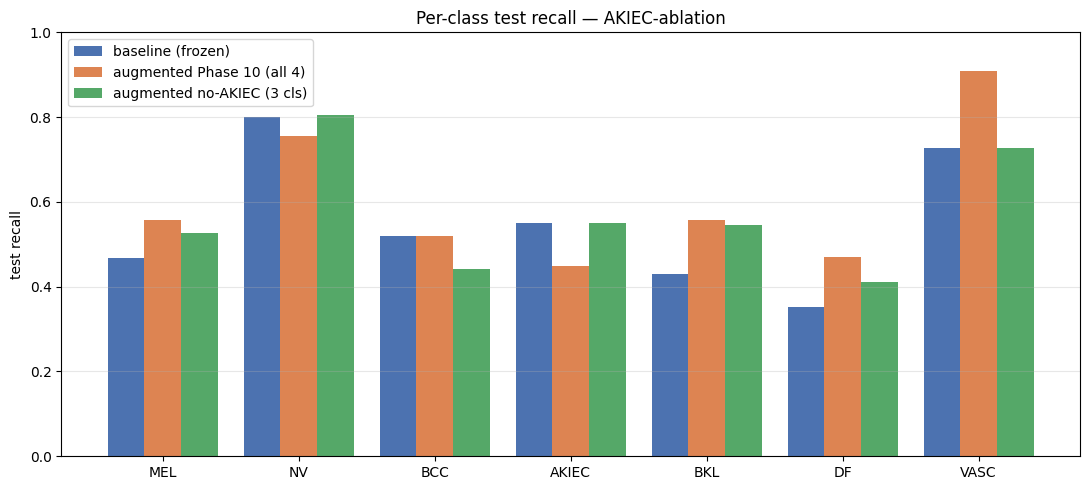

In [14]:
x = np.arange(N_CLASSES)
w = 0.27

p10_baseline  = comparison_df[comparison_df['class'] != 'OVERALL']['baseline_recall'].values
p10_augmented = comparison_df[comparison_df['class'] != 'OVERALL']['augmented_recall'].values
no_akiec      = comparison_df[comparison_df['class'] != 'OVERALL']['no_akiec_recall'].values

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, p10_baseline,  w, label='baseline (frozen)',          color='#4C72B0')
ax.bar(x,     p10_augmented, w, label='augmented Phase 10 (all 4)', color='#DD8452')
ax.bar(x + w, no_akiec,      w, label='augmented no-AKIEC (3 cls)', color='#55A868')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('test recall'); ax.set_ylim(0, 1)
ax.set_title('Per-class test recall — AKIEC-ablation')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out = PLOTS_DIR / 'no_akiec_per_class_recall.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 15. Confusion matrix (row-normalised)

Look at the AKIEC row in particular — without synthetic AKIEC samples, where do real AKIEC test cases get sent?

saved /home/mayarn/skin-cancer/skin-lesion/results/plots/no_akiec_confusion.png


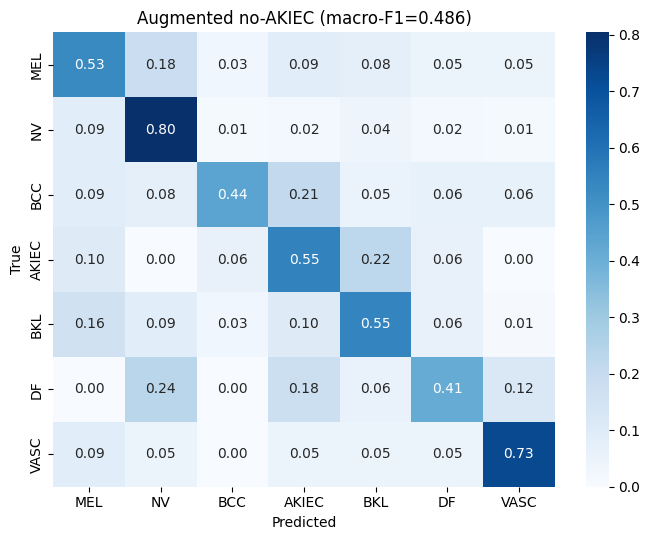

In [15]:
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds, labels=list(range(N_CLASSES)))
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Augmented no-AKIEC (macro-F1={test_f1:.3f})')

plt.tight_layout()
out = PLOTS_DIR / 'no_akiec_confusion.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()

## 16. Results summary

After this notebook runs, look at three numbers from the comparison table above:

1. **Overall macro-F1** — did dropping AKIEC from augmentation improve or hurt the overall score (Phase 10 was 0.603)?
2. **AKIEC recall** — did it recover toward the baseline 0.551 (Phase 10 was 0.449)?
3. **The other classes** (BCC, DF, VASC) — did their gains hold up without the AKIEC samples in the training mix?

Two clean stories the report can tell:

- *If overall macro-F1 went up and AKIEC recovered:* the CVAE-AKIEC samples were poor quality and hurt the model. Conclusion for the report — generative augmentation works, but per-class quality matters more than quantity, and FID alone is not a sufficient quality check (CVAE had the best FID for AKIEC too).
- *If overall macro-F1 stayed flat or dropped:* the AKIEC samples were doing something useful even with the recall trade-off. Conclusion — even noisy synthetic data can carry class signal, and the Phase 10 result is the right one to lead with.

Fill the actual numbers into the report once they come in.